# 0. import

In [ ]:
# --- plot_revision setup (auto-injected) ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.lines import Line2D

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches

from plot_settings import *

from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


In [2]:
chromosomes = {
    'human': [9,10],
    'mouse': [1,2,3,4]
}

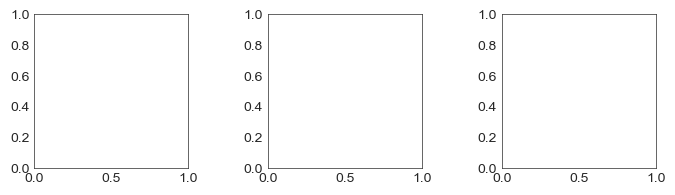

In [3]:
fig = plt.figure(figsize=(8.27, 3))

gs = gridspec.GridSpec(
    3, 3,  
    figure=fig,
    height_ratios=[0.5, 2, 0.5],
    hspace=0.0,
    wspace=0.35
)

axes = []
for i, row in enumerate([1]):
    row_axes = []
    for j in range(3):
        ax = fig.add_subplot(gs[row, j])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)
for ax in axes.flatten():
    ax.set_aspect('equal')
    # ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


In [4]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 3. Embedding umap

## 3.2 ploting

In [5]:
import umap
def read(f, norm=True):
    emb = np.load(f)
    emb = emb.transpose(-1, -2)
    if norm:
        emb /= np.linalg.norm(emb, axis=-1, keepdims=True)
    emb = np.nan_to_num(emb)
    return emb

embeddings = read(str(PRETRAIN_CKPT_DIR / 'human_embeds/dna_emb_10.npy'))

# Step 1: Fit UMAP to reduce to 2D
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=100, min_dist=0.5, metric='cosine')
embeddings_umap = reducer.fit_transform(embeddings)


/home/hanwen/miniconda3/envs/visual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1397245/44739130.py:6: RuntimeWarning: invalid value encountered in divide
  emb /= np.linalg.norm(emb, axis=-1, keepdims=True)
/home/hanwen/miniconda3/envs/visual/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hanwen/miniconda3/envs/visual/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [6]:
a = np.load(str(TRACKS_GM12878_CHR10_NPY))
tracks = [
    'DNase', 
    'CTCF', 
    'H3K27ac',
    'H3K27me3',
    'H3K4me3'
]
print(a.shape)

(5, 66899)


In [7]:
def kde_mean_2d(x, y, val, at=None, bw_method=None):
    """
    计算二维位置上的局部平均信号（核回归）。
    - x,y: 点坐标（1D数组）
    - val: 每个点的信号强度（可正可负）
    - at: 评估位置 (X, Y)；若为 None，则在原始点上评估
          X, Y 可是一维数组(同长度)或网格(np.meshgrid生成的2D数组)
    - bw_method: 传给 gaussian_kde 的带宽（如 'scott'/'silverman' 或浮点因子）
    返回：在 at 位置上的平均信号数组
    """
    x = np.asarray(x); y = np.asarray(y); val = np.asarray(val)
    pts = np.vstack([x, y])

    kde_den = gaussian_kde(pts, bw_method=bw_method)                 # 分母：普通密度
    kde_val = gaussian_kde(pts, weights=val, bw_method=bw_method)  # 分子正部
    
    # 准备评估位置
    if at is None:
        eval_xy = pts
        reshape_to = None
    else:
        X, Y = at
        if X.ndim == 2:  # 网格
            eval_xy = np.vstack([X.ravel(), Y.ravel()])
            reshape_to = X.shape
        else:            # 点集
            eval_xy = np.vstack([X, Y])
            reshape_to = None

    num = kde_val(eval_xy)
    den = kde_den(eval_xy)
    mean = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)

    if reshape_to:
        mean = mean.reshape(reshape_to)
    return mean


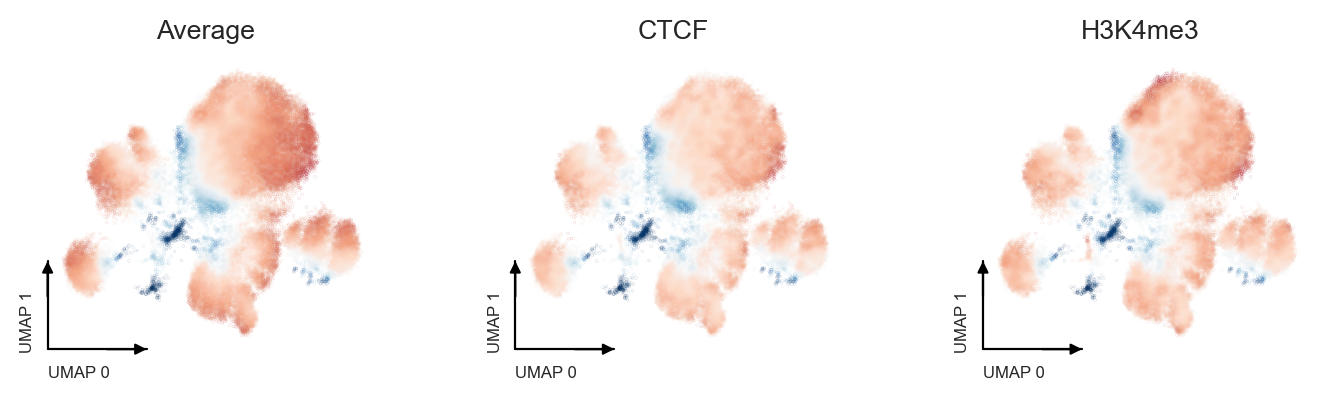

In [8]:


from scipy.stats import rankdata
import matplotlib.gridspec as gridspec

L, R, D = 1000, -1000, 1

percentiles = rankdata(a, axis=-1) / a.shape[-1]

ftracks = ['Average'] + tracks

k = 0.1
boundaries = [0, k, 1-k, 1]

cmap = 'RdBu_r'
norm=None
# cmap = mcolors.ListedColormap(["blue", "lightgrey", "red"])
# norm = mcolors.BoundaryNorm(boundaries, cmap.N)

def plot_umap(embeddings_umap, c, name, ax):
    ax.clear()
    ax.set_aspect('auto')

    x = embeddings_umap[L:R:D, 0]
    y = embeddings_umap[L:R:D, 1]
    val = c[L:R:D]

    mean_at_pts = kde_mean_2d(x, y, val, bw_method=0.05)  # 或 0.5/1.0 等因子微调带宽

    sc = ax.scatter(x, y, c=mean_at_pts, s=0.01, alpha=0.3, cmap=cmap, norm=norm, rasterized=True)

    sns.despine(ax=ax, bottom=True, left=True)
    # ax.set_xlabel('UMAP 0')
    # ax.set_ylabel('UMAP 1')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)

    # 获取当前坐标范围
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # 定义短坐标轴的长度比例
    frac = 0.3
    dx = (xmax - xmin) * frac
    dy = (ymax - ymin) * frac

    # 画出短线段（左下角）
    ax.plot([xmin, xmin + dx], [ymin, ymin], color='black', lw=0.8, clip_on=False)
    ax.plot([xmin, xmin], [ymin, ymin + dy], color='black', lw=0.8, clip_on=False)

    # 加上箭头
    ax.annotate('', xy=(xmin + dx, ymin), xytext=(xmin + dx*0.6, ymin),
                arrowprops=dict(arrowstyle='-|>', lw=0.8, color='black', shrinkA=0, shrinkB=0))
    ax.annotate('', xy=(xmin, ymin + dy), xytext=(xmin, ymin + dy*0.6),
                arrowprops=dict(arrowstyle='-|>', lw=0.8, color='black', shrinkA=0, shrinkB=0))

    # 可选：在箭头附近加个标签
    ax.text(xmin, ymin-1, 'UMAP 0', va='center', fontsize=6)
    ax.text(xmin-1, ymin, 'UMAP 1', ha='center', rotation=90, fontsize=6)

    return sc

sc1 = plot_umap(embeddings_umap, percentiles.mean(axis=0), ftracks[0], axes[0][0])
sc2 = plot_umap(embeddings_umap, percentiles[1], tracks[1], axes[0][1])
sc3 = plot_umap(embeddings_umap, percentiles[4], tracks[4], axes[0][2])

fig

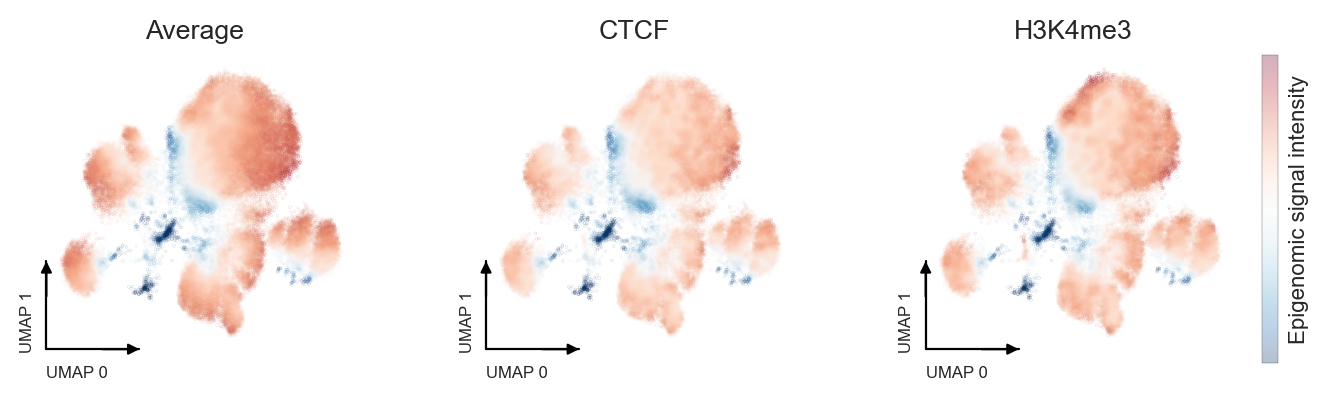

In [9]:
# 在最右侧加一个共用 colorbar
cb = fig.colorbar(sc3, ax=axes[0].ravel().tolist(), location='right',
                  fraction=0.04, pad=0.02)  # 可微调 fraction/pad
cb.outline.set_linewidth(0.1)
cb.set_ticks([])
cb.set_label('Epigenomic signal intensity')

fig

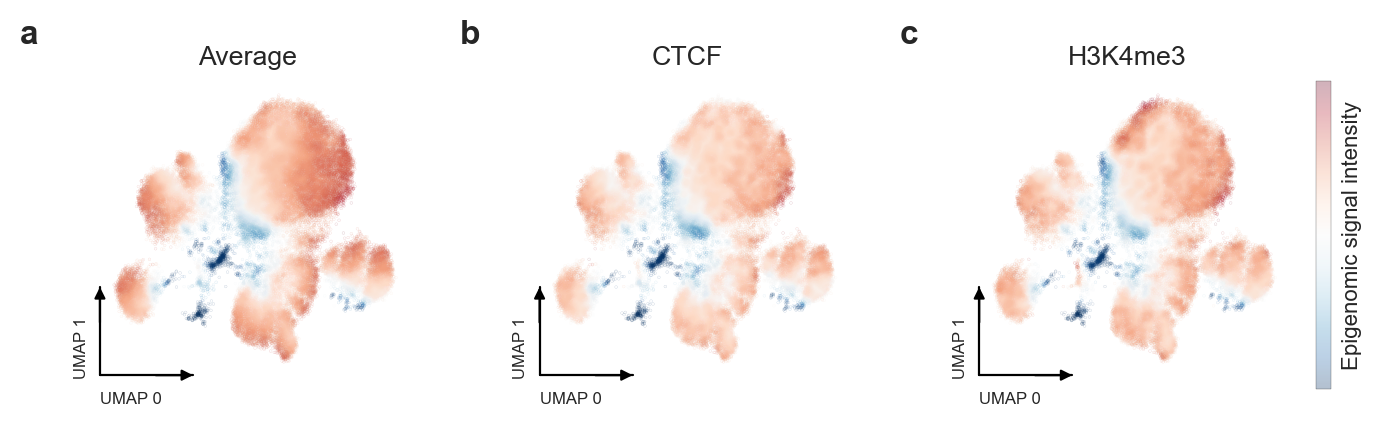

In [10]:
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i','j']
axs = [axes[0][0], axes[0][1], axes[0][2]]

for ax, label in zip(axs, labels):
    ax.text(
        -0.2, 1.2, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig

In [12]:
fig.savefig(str(OUT_DIR / 'supplementary_2.pdf'), dpi=600)